# CDSD JAX 完整训练流程 - SAVAR 数据集 (PICABU 擴展版)

**JAX/Flax 版本特性：**
- ✅ JAX 自动微分和 JIT 编译
- ✅ GPU 支持（自动检测）
- ✅ Flax 神经网络模块
- ✅ Optax 优化器
- ✅ 从数据集自动读取参数
- ✅ 配置系统（方便多次实验）
- ✅ 完整的可视化
- ✅ **PICABU 損失函數（CRPS + Spectral Loss）**

## PICABU 擴展說明
本版本整合了 PICABU 論文的改進：
- **CRPS (Continuous Ranked Probability Score)**：機率預測準確度損失
- **Spectral Loss**：空間功率譜 L1 距離，保持空間結構

## 训练步骤：
1. 环境设置和配置
2. 数据加载（自动读取参数）
3. 模型初始化
4. 训练（ALM/QPM 约束优化 + PICABU 損失）
5. 评估
6. 可视化

## 1. 环境设置

In [1]:
import os
os.environ["CDSD_DISABLE_PLOTS"]="1"

import sys

import json
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# ✅ 導入 PICABU JAX 模組
from picabu_jax.data_loader_jax import DataLoaderJAX
from picabu_jax.model.picabu_latent import TSDCDConfig
from picabu_jax.train_picabu_latent import TrainingLatentJAX
from picabu_jax.metrics_jax import mcc_latent, shd, precision_recall, edge_errors, w_mae

# ✅ 導入 PICABU 損失模組
try:
    from picabu_jax.spectral_losses import (
        crps_loss,
        temporal_spectral_loss,
        picabu_auxiliary_loss
    )
    PICABU_AVAILABLE = True
    print("✓ PICABU losses module loaded")
except ImportError:
    PICABU_AVAILABLE = False
    print("⚠ PICABU losses module not found (will use fallback)")

print(f"✓ JAX {jax.__version__}")
print(f"✓ Devices: {jax.devices()}")
print(f"✓ Default backend: {jax.default_backend()}")
print("✓ All PICABU JAX modules imported successfully!")


✓ PICABU losses module loaded
✓ JAX 0.7.2
✓ Devices: [CpuDevice(id=0)]
✓ Default backend: cpu
✓ All PICABU JAX modules imported successfully!


## 2. 配置参数

### PICABU 新增配置：
- `use_auxiliary_losses`: 是否啟用 PICABU 輔助損失（CRPS + Temporal Spectral）
  - **注意**：Top-K ALM Sparsity Constraint 永遠啟用，不受此參數影響
- `coeff_crps`: CRPS 損失係數（默認 1.0）
- `coeff_temporal`: Temporal Spectral 損失係數（默認 2000.0）
- `sparsity_ratio`: Top-K 稀疏比例（默認 0.5，即 M = 0.5 * d_z）

### 使用方式：
1. **快速开始**：直接运行，使用默认配置
2. **自定义实验**：修改 `CONFIG` 字典中的参数
3. **批量实验**：修改 `exp_id` 和其他参数，重复运行

In [ ]:
# ==================== 实验配置 ====================
CONFIG = {
    # === 数据集 ===
    'data_path': "dataset/savar_N25_med-easy_seed0",
    'use_data_config': True,  # 是否从数据集自动读取 d_z, d_x, tau
    
    # === 实验输出 ===
    'exp_base_path': "picabu_jax_results",
    'exp_name': "savar_N25_jax_picabu",  # ← 修改：加上 _picabu 標識
    'exp_id': 0,  # 实验编号（exp0, exp1, exp2, ...）
    
    # === 设备 ===
    'use_gpu': True,  # 自动检测并使用 GPU（如果可用）
    
    # === 训练超参数 ===
    'max_iteration': 50000,  # 完整训练用 50000-100000，快速测试用 5000-10000
    'patience': 5000,
    'patience_post_thresh': 50,
    'batch_size': 64,
    'lr': 0.001,
    'ratio_train': 0.8,
    'ratio_valid': 0.2,
    
    # ===== Model Architecture =====
    'num_layers': 0,
    'num_hidden': 0,            # encoder/decoder
    'num_layers_mixing': 0,
    'num_hidden_mixing': 0,      # transition model
    
    # === 正则化 ===
    'reg_coeff': 1e-3,
    'coeff_kl': 1.0,
    'schedule_reg': 1000,
    'schedule_ortho': 0,
    
    # === 优化器 ===
    'optimizer': "rmsprop",
    'random_seed': 1,
    
    # === 日志频率 ===
    'valid_freq': 100,
    'print_freq': 1,
    'plot_freq': 10,
    
    # === ALM/QPM 约束优化 ===
    # 正交性约束（混合矩阵 W）
    'ortho_mu_init': 1e2,
    'ortho_mu_mult_factor': 1.2,
    'ortho_omega_gamma': 0.01,
    'ortho_omega_mu': 0.9,
    'ortho_h_threshold': 1e-4,
    'ortho_min_iter_convergence': 100,
    
    # 无环性约束（只在 instantaneous=True 时使用）
    'acyclic_mu_init': 1e1,
    'acyclic_mu_mult_factor': 2,
    'acyclic_omega_gamma': 0.01,
    'acyclic_omega_mu': 0.9,
    'acyclic_h_threshold': 1e-8,
    'acyclic_min_iter_convergence': 1000,
    
    # ==================== SAVAR-PICABU 配置 ====================
    # 注意：Top-K ALM Sparsity 永遠啟用
    # use_auxiliary_losses 只控制 CRPS + Temporal Spectral Loss
    'use_auxiliary_losses': True,  # ← 啟用 PICABU 輔助損失
    'coeff_crps': 1.0,             # CRPS 損失係數（論文默認值）
    'coeff_temporal': 2000.0,      # Temporal Spectral 係數（論文默認值）
    'target_edges': None,          # 可選：指定目標邊集以計算輔助損失
    'sparsity_mu_init': 0.01,       # Sparsity ALM 初始 μ
    'sparsity_mu_mult': 1.5,       # Sparsity ALM μ 乘數
    # ==========================================================
}

# 打印配置
print("Configuration:")
print(f"  Data: {CONFIG['data_path']}")
print(f"  Auto-read data config: {CONFIG['use_data_config']}")

# 检查 GPU 是否可用（安全方式）
try:
    gpu_available = len(jax.devices('gpu')) > 0
except RuntimeError:
    gpu_available = False

print(f"  Use GPU: {CONFIG['use_gpu']} (available: {gpu_available})")
print(f"  Max iterations: {CONFIG['max_iteration']}")
print(f"  Experiment: {CONFIG['exp_base_path']}/{CONFIG['exp_name']}/exp{CONFIG['exp_id']}")

# PICABU 配置
print(f"\n  === PICABU 配置 ===")
# print(f"  Top-K Sparsity: ALWAYS ENABLED (ratio={CONFIG['sparsity_ratio']})")
print(f"  Auxiliary Losses: {'ENABLED' if CONFIG['use_auxiliary_losses'] else 'DISABLED'}")
if CONFIG['use_auxiliary_losses']:
    print(f"    - coeff_crps: {CONFIG['coeff_crps']}")
    print(f"    - coeff_temporal: {CONFIG['coeff_temporal']}")


Configuration:
  Data: dataset/savar_N25_med-easy_seed0
  Auto-read data config: True
  Use GPU: True (available: False)
  Max iterations: 50000
  Experiment: picabu_jax_results/savar_N25_jax_picabu/exp0

  === PICABU 配置 ===
  Auxiliary Losses: ENABLED
    - coeff_crps: 1.0
    - coeff_temporal: 2000.0


## 3. 设置随机种子和实验目录

In [3]:
# 设置随机种子
np.random.seed(CONFIG['random_seed'])
rng_seed = CONFIG['random_seed']

# 创建实验目录
exp_path = os.path.join(
    CONFIG['exp_base_path'], 
    CONFIG['exp_name'], 
    f"exp{CONFIG['exp_id']}"
)
os.makedirs(exp_path, exist_ok=True)

print(f"✓ Random seed: {rng_seed}")
print(f"✓ Experiment directory: {exp_path}")

✓ Random seed: 1
✓ Experiment directory: picabu_jax_results/savar_N25_jax_picabu/exp0


## 4. 载入数据（自动读取参数）

In [4]:
print("Loading data...")

# 从数据集自动读取参数（如果启用）
if CONFIG['use_data_config']:
    data_params_path = os.path.join(CONFIG['data_path'], "data_params.json")
    if os.path.exists(data_params_path):
        with open(data_params_path, 'r') as f:
            data_params = json.load(f)
        
        d_x = data_params.get('d_x', 100)
        d_z = data_params.get('d_z', 25) if data_params.get('latent', True) else None
        tau = data_params.get('tau', 1)
        instantaneous = False  # SAVAR 固定使用 False
        
        print(f"✓ Auto-read from data_params.json:")
        print(f"  d_x = {d_x}")
        print(f"  d_z = {d_z}")
        print(f"  tau = {tau}")
    else:
        print("⚠ data_params.json not found, using defaults")
        d_x = 100
        d_z = 25
        tau = 1
        instantaneous = False
else:
    # 手动指定参数
    d_x = 100
    d_z = 25
    tau = 1
    instantaneous = False
    print("Using manual configuration")

# 加载数据
data_loader = DataLoaderJAX(
    ratio_train=CONFIG['ratio_train'],
    ratio_valid=CONFIG['ratio_valid'],
    data_path=CONFIG['data_path'],
    data_format="numpy",
    latent=True,
    no_gt=False,
    debug_gt_w=False,
    instantaneous=instantaneous,
    tau=tau,
    seed=CONFIG['random_seed']
)

print(f"\n✓ Data loaded successfully!")
print(f"  X shape: {data_loader.x.shape}")
print(f"  Z shape: {data_loader.z.shape if data_loader.z is not None else None}")
print(f"  Train samples: {data_loader.n_train}")
print(f"  Valid samples: {data_loader.n_valid}")
print(f"  GT graph shape: {data_loader.gt_graph.shape if data_loader.gt_graph is not None else None}")
print(f"  GT W shape: {data_loader.gt_w.shape if data_loader.gt_w is not None else None}")

Loading data...
✓ Auto-read from data_params.json:
  d_x = 100
  d_z = 25
  tau = 1

✓ Data loaded successfully!
  X shape: (1, 2000, 1, 100)
  Z shape: (1, 2000, 1, 25)
  Train samples: 1580
  Valid samples: 400
  GT graph shape: (1, 25, 25)
  GT W shape: (1, 100, 25)


## 5. 初始化模型

In [5]:
gt_graph = data_loader.gt_graph
print(f"gt_graph.shape: {gt_graph.shape}")
print(f"gt_graph.sum() = {gt_graph.sum()}")

gt_graph.shape: (1, 25, 25)
gt_graph.sum() = 50.0


In [6]:
print("Initializing model...")

d = data_loader.x.shape[2]

model = TSDCDConfig(
    d=d,
    d_x=d_x,
    d_z=d_z,
    tau=tau,
    num_layers=CONFIG['num_layers'],
    num_hidden=CONFIG['num_hidden'],
    num_layers_mixing=CONFIG['num_layers_mixing'],
    num_hidden_mixing=CONFIG['num_hidden_mixing'],
    coeff_kl=CONFIG['coeff_kl'],
    instantaneous=instantaneous,
    nonlinear_mixing=False,
    hard_gumbel=True,
    tied_w=False
)

print(f"\n✓ Model config initialized!")
print(f"  Model: TSDCDConfig (Functional JAX)")
print(f"  d={d}, d_x={d_x}, d_z={d_z}, tau={tau}")

Initializing model...

✓ Model config initialized!
  Model: TSDCDConfig (Functional JAX)
  d=1, d_x=100, d_z=25, tau=1


## 6. 准备训练器（含 PICABU 配置）

In [7]:
print("Setting up trainer...")

# 创建超参数对象
class HParams:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

hp = HParams(
    # 数据相关
    latent=True,
    no_gt=False,
    debug_gt_z=False,
    d_z=d_z,
    d_x=d_x,
    tau=tau,
    instantaneous=instantaneous,
    no_w_constraint=False,
    
    # 训练相关
    batch_size=CONFIG['batch_size'],
    max_iteration=CONFIG['max_iteration'],
    patience=CONFIG['patience'],
    patience_post_thresh=CONFIG['patience_post_thresh'],
    
    # 优化器
    optimizer=CONFIG['optimizer'],
    lr=CONFIG['lr'],
    
    # 正则化
    reg_coeff=CONFIG['reg_coeff'],
    schedule_reg=CONFIG['schedule_reg'],
    schedule_ortho=CONFIG['schedule_ortho'],
    
    # ALM/QPM - 正交性约束
    ortho_mu_init=CONFIG['ortho_mu_init'],
    ortho_mu_mult_factor=CONFIG['ortho_mu_mult_factor'],
    ortho_omega_gamma=CONFIG['ortho_omega_gamma'],
    ortho_omega_mu=CONFIG['ortho_omega_mu'],
    ortho_h_threshold=CONFIG['ortho_h_threshold'],
    ortho_min_iter_convergence=CONFIG['ortho_min_iter_convergence'],
    
    # ALM/QPM - 无环性约束
    acyclic_mu_init=CONFIG['acyclic_mu_init'],
    acyclic_mu_mult_factor=CONFIG['acyclic_mu_mult_factor'],
    acyclic_omega_gamma=CONFIG['acyclic_omega_gamma'],
    acyclic_omega_mu=CONFIG['acyclic_omega_mu'],
    acyclic_h_threshold=CONFIG['acyclic_h_threshold'],
    acyclic_min_iter_convergence=CONFIG['acyclic_min_iter_convergence'],
    
    # 日志
    valid_freq=CONFIG['valid_freq'],
    print_freq=CONFIG['print_freq'],
    plot_freq=CONFIG['plot_freq'],
    graph_history_limit=50,
    plot_through_time=False,
    exp_path=exp_path,
    
    # ==================== SAVAR-PICABU 參數 ====================
    use_auxiliary_losses=CONFIG['use_auxiliary_losses'],
    coeff_crps=CONFIG['coeff_crps'],
    coeff_temporal=CONFIG['coeff_temporal'],
    # sparsity_ratio=CONFIG['sparsity_ratio'],
    sparsity_mu_init=CONFIG['sparsity_mu_init'],
    sparsity_mu_mult=CONFIG['sparsity_mu_mult'],
    # ==========================================================
)

# 载入 best_metrics
best_metrics_path = os.path.join(CONFIG['data_path'], 'best_metrics.json')
if os.path.exists(best_metrics_path):
    with open(best_metrics_path, 'r') as f:
        best_metrics = json.load(f)
else:
    # 使用默认值
    best_metrics = {
        "shd": 0.0,
        "mcc": 0.0,
        "recons": 0.0,
        "kl": 0.0,
        "elbo": 0.0
    }
    print("⚠ best_metrics.json not found, using defaults")

# 创建训练器
trainer = TrainingLatentJAX(
    model=model,
    data=data_loader,
    hp=hp,
    best_metrics=best_metrics,
    rng_seed=rng_seed
)

print("\n✓ Trainer ready!")
print(f"  Using TrainingLatentJAX with ALM/QPM constraints")
if CONFIG['use_auxiliary_losses']:
    print(f"  PICABU auxiliary losses enabled")
    print(f"    - coeff_crps={CONFIG['coeff_crps']}")
    print(f"    - coeff_temporal={CONFIG['coeff_temporal']}")


Setting up trainer...

=== SAVAR-PICABU Configuration ===
  instantaneous: False
  tau: 1
  target_edges: 50 (from gt_graph.sum())
  Training: ALM soft penalty only

Plotting disabled: disabled
=== Validation ===
  adj shape: (1, 25, 25)
  target_edges: 50


✓ Trainer ready!
  Using TrainingLatentJAX with ALM/QPM constraints
  PICABU auxiliary losses enabled
    - coeff_crps=1.0
    - coeff_temporal=2000.0


## 7. 开始训练

完整的训练流程包括：
1. **ALM/QPM 优化阶段**：优化正交性约束
2. **PICABU 損失**：CRPS + Spectral Loss（在 schedule_reg 之後啟用）
3. **继续训练阶段**：直到验证损失稳定
4. **阈值化阶段**：将邻接矩阵二值化
5. **微调阶段**：在固定图结构下微调参数

In [8]:
print("\n" + "="*70)
print("Starting Training with ALM/QPM Constraint Optimization (JAX)")
if CONFIG['use_auxiliary_losses']:
    print("+ PICABU Auxiliary Losses (CRPS + Temporal Spectral)")
print("+ Top-K ALM Sparsity Constraint (ALWAYS ENABLED)")
print("="*70)
print(f"Max iterations: {CONFIG['max_iteration']}")
print(f"Validation every {CONFIG['valid_freq']} iterations")
print(f"Patience: {CONFIG['patience']}")
print(f"Device: {jax.default_backend().upper()}")
if CONFIG['use_auxiliary_losses']:
    print(f"PICABU Auxiliary: coeff_crps={CONFIG['coeff_crps']}, coeff_temporal={CONFIG['coeff_temporal']}")
# print(f"Sparsity ratio: {CONFIG['sparsity_ratio']} (target edges = {int(CONFIG['sparsity_ratio'] * d_z)})")
print("="*70 + "\n")

# 训练
start_time = time.time()
valid_loss = trainer.train_with_QPM()
training_time = time.time() - start_time

print("\n" + "="*70)
print(f"Training completed in {training_time:.2f}s ({training_time/60:.2f} min)")
print("="*70)



Starting Training with ALM/QPM Constraint Optimization (JAX)
+ PICABU Auxiliary Losses (CRPS + Temporal Spectral)
+ Top-K ALM Sparsity Constraint (ALWAYS ENABLED)
Max iterations: 50000
Validation every 100 iterations
Patience: 5000
Device: CPU
PICABU Auxiliary: coeff_crps=1.0, coeff_temporal=2000.0

Iteration #100 | Converged: False | Thresholded: False
ELBO: -286.6171 | Recons: -133.3201 | KL: 153.2970
Sparsity: 0.0 (target=50) | μ=0.01
Ortho: -3.7e-03 | Acyclic: 0.0000
Valid ELBO: -270.1797 | Patience: 5000
Iteration #200 | Converged: False | Thresholded: False
ELBO: -236.4288 | Recons: -124.9282 | KL: 111.5006
Sparsity: 0.0 (target=50) | μ=0.01
Ortho: -4.4e-03 | Acyclic: 0.0000
Valid ELBO: -227.9114 | Patience: 5000
Iteration #300 | Converged: False | Thresholded: False
ELBO: -174.3988 | Recons: -110.5394 | KL: 63.8594
Sparsity: 0.0 (target=50) | μ=0.01
Ortho: -3.7e-04 | Acyclic: 0.0000
Valid ELBO: -170.2218 | Patience: 5000
Iteration #400 | Converged: False | Thresholded: False
EL

## 8. 獲取學習到的鄰接矩陣

In [9]:
# 获取学习的邻接矩阵
learned_adj = trainer.get_adj()
learned_adj_np = np.array(learned_adj)

print(f"Learned adjacency shape: {learned_adj_np.shape}")
print(f"Adjacency probability range: [{learned_adj_np.min():.4f}, {learned_adj_np.max():.4f}]")


Learned adjacency shape: (1, 25, 25)
Adjacency probability range: [0.0000, 1.0000]


## 9. 評估指標

In [10]:
print("Evaluating results...")

# Ground truth
gt_graph = trainer.gt_dag
gt_w = data_loader.gt_w

# 只在這裡做一次二值化（不改 params）
adj_bin = trainer.threshold(method="adaptive_topk")
learned_graph = np.array(adj_bin)

# 如果 gt_graph 有多層而你只想比某一層，再在這裡處理
# 目前 instantaneous=False → 你是用整張圖，就不用切 [-1]

# MCC + latent permutation
score, cc_program_perm, assignments, z, z_hat, _ = mcc_latent(
    trainer,
    trainer.data,
    num_samples=min(10000, data_loader.n_valid),
    rng=trainer.rng
)

permutation = np.zeros((gt_graph.shape[1], gt_graph.shape[1]))
permutation[np.arange(gt_graph.shape[1]), assignments[1]] = 1
gt_graph_permuted = permutation.T @ gt_graph @ permutation

# 硬檢查 shape 一致
assert learned_graph.shape == gt_graph_permuted.shape, \
    f"Shape mismatch: learned {learned_graph.shape}, gt {gt_graph_permuted.shape}"

# 評估指標
learned_w = np.array(trainer.get_w_decoder())
metrics = {
    'mcc': float(score),
    'w_mae': float(w_mae(
        learned_w[:, :, assignments[1]],
        gt_w
    )),
    'shd': float(shd(learned_graph, gt_graph_permuted)),
    'training_time': training_time,
    'n_iterations': int(trainer.iteration),
    'converged': bool(trainer.converged),
    'thresholded': bool(trainer.thresholded),
}

prec, rec = precision_recall(learned_graph, gt_graph_permuted)
metrics['precision'] = float(prec)
metrics['recall'] = float(rec)

errors = edge_errors(learned_graph, gt_graph_permuted)
metrics.update(errors)

metrics['n_edge_gt_graph'] = float(np.sum(gt_graph_permuted))
metrics['n_edge_learned_graph'] = float(np.sum(learned_graph))

if CONFIG['use_auxiliary_losses'] and hasattr(trainer, 'train_crps_list') and len(trainer.train_crps_list) > 0:
    metrics['final_crps'] = float(trainer.train_crps_list[-1])
    # metrics['final_temporal'] = float(trainer.train_temporal_list[-1])

# print 區塊維持不變

print("" + "="*70)
print("Causal Structure Evaluation")
print("="*70)
print(f"MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"SHD (graph distance):   {metrics['shd']:.1f}")
print(f"Precision:              {metrics['precision']:.4f}")
print(f"Recall:                 {metrics['recall']:.4f}")
print(f"W MAE:                  {metrics['w_mae']:.4f}")
print(f"True Positives:  {metrics['tp']}")
print(f"False Positives: {metrics['fp']}")
print(f"True Negatives:  {metrics['tn']}")
print(f"False Negatives: {metrics['fn']}")
print(f"GT edges:      {metrics['n_edge_gt_graph']:.0f}")
print(f"Learned edges: {metrics['n_edge_learned_graph']:.0f}")

if 'final_crps' in metrics:
    print(f"PICABU Auxiliary Loss Metrics:")
    print(f"  Final CRPS:     {metrics['final_crps']:.4f}")
    # print(f"  Final Temporal: {metrics['final_temporal']:.4f}")

print("="*70)



Evaluating results...
Thresholding: 50 edges (target=50)
Causal Structure Evaluation
MCC (latent recovery):  0.8107
SHD (graph distance):   23.0
Precision:              0.7600
Recall:                 0.7600
W MAE:                  0.0052
True Positives:  38.0
False Positives: 12.0
True Negatives:  563.0
False Negatives: 12.0
GT edges:      50
Learned edges: 50
PICABU Auxiliary Loss Metrics:
  Final CRPS:     0.0663


## 10. 保存結果

In [11]:
# 保存结果
results_path = os.path.join(exp_path, 'results.json')
with open(results_path, 'w') as f:
    json.dump(metrics, f, indent=2)

# 保存配置
config_path = os.path.join(exp_path, 'config.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f"✓ Results saved to {results_path}")
print(f"✓ Config saved to {config_path}")

✓ Results saved to picabu_jax_results/savar_N25_jax_picabu/exp0/results.json
✓ Config saved to picabu_jax_results/savar_N25_jax_picabu/exp0/config.json


## 11. 可視化：訓練曲線（含 PICABU 損失）

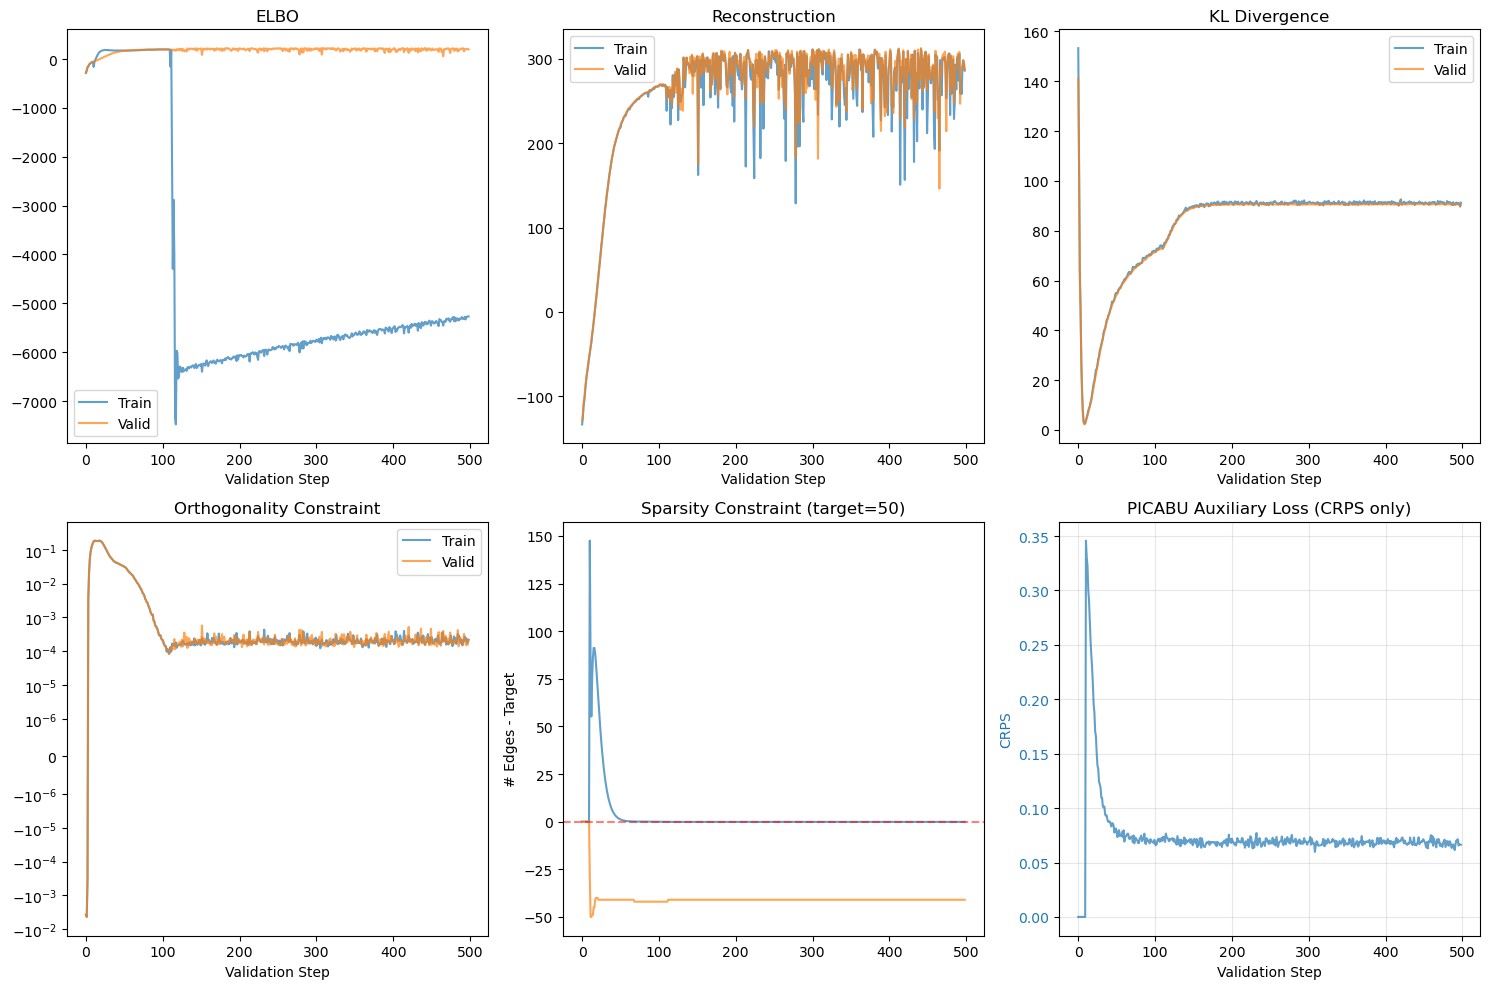

✓ Training curves saved to picabu_jax_results/savar_N25_jax_picabu/exp0/training_curves.png


In [12]:
# 绘制训练曲线
n_plots = 5 if not CONFIG['use_auxiliary_losses'] else 6
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# ELBO
axes[0].plot(trainer.train_loss_list, label='Train', alpha=0.7)
axes[0].plot(trainer.valid_loss_list, label='Valid', alpha=0.7)
axes[0].set_title('ELBO')
axes[0].legend()
axes[0].set_xlabel('Validation Step')

# Reconstruction
axes[1].plot(trainer.train_recons_list, label='Train', alpha=0.7)
axes[1].plot(trainer.valid_recons_list, label='Valid', alpha=0.7)
axes[1].set_title('Reconstruction')
axes[1].legend()
axes[1].set_xlabel('Validation Step')

# KL
axes[2].plot(trainer.train_kl_list, label='Train', alpha=0.7)
axes[2].plot(trainer.valid_kl_list, label='Valid', alpha=0.7)
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].set_xlabel('Validation Step')

# Orthogonality constraint
axes[3].plot(trainer.train_ortho_cons_list, label='Train', alpha=0.7)
axes[3].plot(trainer.valid_ortho_cons_list, label='Valid', alpha=0.7)
axes[3].set_title('Orthogonality Constraint')
axes[3].legend()
axes[3].set_xlabel('Validation Step')
axes[3].set_yscale('symlog', linthresh=1e-6)

# Sparsity regularization
axes[4].plot(trainer.train_sparsity_list, label='Train', alpha=0.7)  # ← 改這裡
axes[4].plot(trainer.valid_sparsity_list, label='Valid', alpha=0.7)  # ← 改這裡
axes[4].set_title(f'Sparsity Constraint (target={trainer.target_edges})')
axes[4].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Target')
axes[4].set_ylabel('# Edges - Target')

# PICABU auxiliary losses（如果啟用）
if CONFIG['use_auxiliary_losses'] and hasattr(trainer, 'train_crps_list') and len(trainer.train_crps_list) > 0:
    ax_picabu = axes[5]
    ax_picabu.plot(trainer.train_crps_list, label='CRPS', alpha=0.7, color='tab:blue')
    ax_picabu.set_ylabel('CRPS', color='tab:blue')
    ax_picabu.tick_params(axis='y', labelcolor='tab:blue')
    ax_picabu.set_xlabel('Validation Step')
    ax_picabu.grid(True, alpha=0.3)
    
    # 檢查 temporal loss 是否存在且非零
    if (hasattr(trainer, 'train_temporal_list') and 
        len(trainer.train_temporal_list) > 0 and 
        max(trainer.train_temporal_list) > 0):
        ax_picabu2 = ax_picabu.twinx()
        ax_picabu2.plot(trainer.train_temporal_list, label='Temporal', alpha=0.7, color='tab:orange')
        ax_picabu2.set_ylabel('Temporal Spectral', color='tab:orange')
        ax_picabu2.tick_params(axis='y', labelcolor='tab:orange')
        ax_picabu.set_title('PICABU Auxiliary Losses (CRPS + Temporal)')
    else:
        ax_picabu.set_title('PICABU Auxiliary Loss (CRPS only)')
else:
    axes[5].axis('off')
    axes[5].text(0.5, 0.5, 'Auxiliary losses not enabled', 
                ha='center', va='center', fontsize=12)


plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved to {exp_path}/training_curves.png")


## 12. 可視化：學習的圖 vs Ground Truth

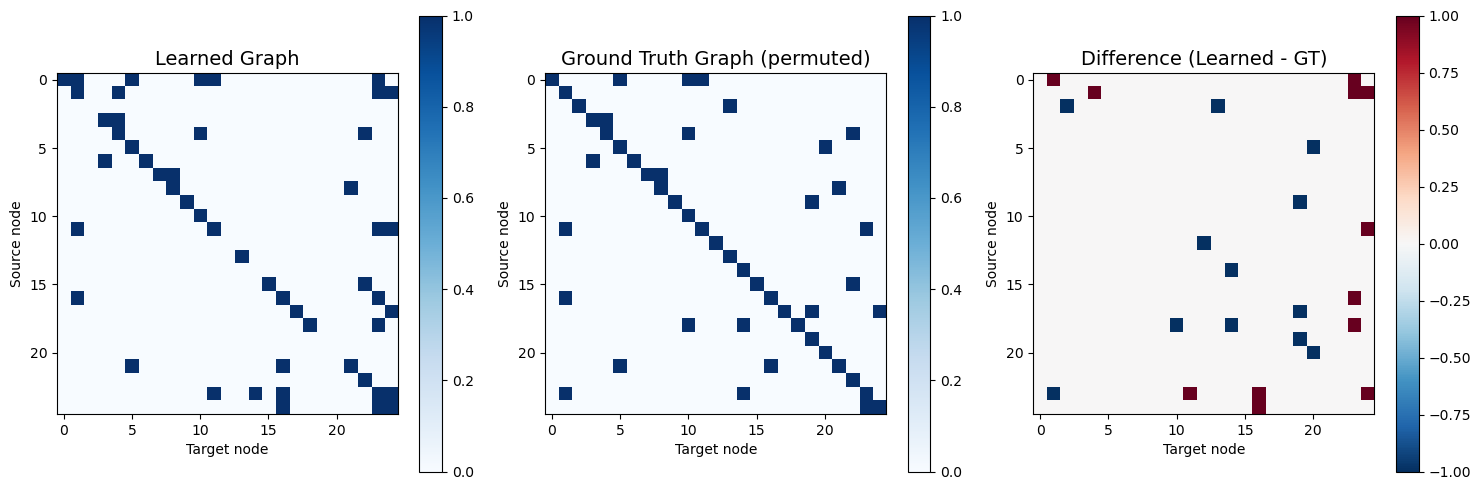

✓ Graph comparison saved to picabu_jax_results/savar_N25_jax_picabu/exp0/learned_vs_gt_graph.png


In [13]:
# 可视化学习的图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Learned Graph
im1 = axes[0].imshow(learned_graph[0], cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Learned Graph', fontsize=14)
axes[0].set_xlabel('Target node')
axes[0].set_ylabel('Source node')
plt.colorbar(im1, ax=axes[0])

# Ground Truth (permuted to match learned latent variables)
im2 = axes[1].imshow(gt_graph_permuted[0], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Ground Truth Graph (permuted)', fontsize=14)
axes[1].set_xlabel('Target node')
axes[1].set_ylabel('Source node')
plt.colorbar(im2, ax=axes[1])

# Difference
diff = learned_graph[0] - gt_graph_permuted[0]
im3 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_title('Difference (Learned - GT)', fontsize=14)
axes[2].set_xlabel('Target node')
axes[2].set_ylabel('Source node')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'learned_vs_gt_graph.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Graph comparison saved to {exp_path}/learned_vs_gt_graph.png")

## 13. 完整結果摘要

In [14]:
print("\n" + "="*70)
print("COMPLETE RESULTS SUMMARY (JAX + PICABU)")
print("="*70)

print("\n📊 Causal Structure Discovery:")
print(f"  MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"  SHD (graph distance):   {metrics['shd']:.1f}")
print(f"  Precision:              {metrics['precision']:.4f}")
print(f"  Recall:                 {metrics['recall']:.4f}")
print(f"  W MAE:                  {metrics['w_mae']:.4f}")

if CONFIG['use_auxiliary_losses']:
    print("\n🎯 PICABU Auxiliary Loss Metrics:")
    if 'final_crps' in metrics:
        print(f"  Final CRPS:             {metrics['final_crps']:.4f}")
        # print(f"  Final Temporal:         {metrics['final_temporal']:.4f}")
    else:
        print(f"  (Metrics not available)")

print("\n⚙️ Training Info:")
print(f"  Time:       {training_time:.2f}s ({training_time/60:.2f} min)")
print(f"  Iterations: {trainer.iteration}")
print(f"  Device:     {jax.default_backend().upper()}")
print(f"  Framework:  JAX/Flax")
# print(f"  Top-K Sparsity: ALWAYS ENABLED (ratio={CONFIG['sparsity_ratio']})")
print(f"  Auxiliary Losses: {'ENABLED' if CONFIG['use_auxiliary_losses'] else 'DISABLED'}")

print("\n💾 Saved Files:")
print(f"  {exp_path}/")
print(f"    - results.json (完整评估指标)")
print(f"    - config.json (实验配置)")
print(f"    - training_curves.png")
print(f"    - learned_vs_gt_graph.png")

print("\n" + "="*70)
print("✓ ALL DONE!")
print("="*70)



COMPLETE RESULTS SUMMARY (JAX + PICABU)

📊 Causal Structure Discovery:
  MCC (latent recovery):  0.8107
  SHD (graph distance):   23.0
  Precision:              0.7600
  Recall:                 0.7600
  W MAE:                  0.0052

🎯 PICABU Auxiliary Loss Metrics:
  Final CRPS:             0.0663

⚙️ Training Info:
  Time:       664.38s (11.07 min)
  Iterations: 50000
  Device:     CPU
  Framework:  JAX/Flax
  Auxiliary Losses: ENABLED

💾 Saved Files:
  picabu_jax_results/savar_N25_jax_picabu/exp0/
    - results.json (完整评估指标)
    - config.json (实验配置)
    - training_curves.png
    - learned_vs_gt_graph.png

✓ ALL DONE!
